# Jet Image VAE Training

In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths (Adjust these to match your Drive structure)
DRIVE_BASE_DIR = '/content/drive/MyDrive/VAE/'

# Copy from Drive to local VM storage (very fast transfer)
!cp "/content/drive/MyDrive/VAE/quark-gluon_data-set_n139306.hdf5" "/content/dataset.hdf5"

# Point your code to the NEW local path
H5_PATH = "/content/dataset.hdf5"
OUTPUT_DIR = os.path.join(DRIVE_BASE_DIR, 'runs/vae_colab')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset Path: {H5_PATH}")
print(f"Output Directory: {OUTPUT_DIR}")

Mounted at /content/drive
Dataset Path: /content/dataset.hdf5
Output Directory: /content/drive/MyDrive/VAE/runs/vae_colab


In [ ]:
!pip install -r '/content/drive/MyDrive/VAE/requirements.txt'

## 1. Optimized Data Loading (Load back to RAM)

In [ ]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import time
import os
import sys


In [ ]:
# 1. Open the HDF5 file
with h5py.File('/content/dataset.hdf5', 'r') as f:
    # 2. Access 'X_jets' and load into memory
    x_jets_mem = f['X_jets'][:]

# 3. File is automatically closed by the 'with' block

# 4. Print shape and memory usage
mem_usage_gb = x_jets_mem.nbytes / (1024**3)
print(f"Data loaded successfully.")
print(f"Array Shape: {x_jets_mem.shape}")
print(f"Memory Usage: {mem_usage_gb:.2f} GB")

Data loaded successfully.
Array Shape: (139306, 125, 125, 3)
Memory Usage: 24.33 GB


## 2. Optimized Dataset Class

In [ ]:
class JetImageDataset(Dataset):
    def __init__(self, data):
        super(JetImageDataset, self).__init__()
        self.images = data
        self.length = len(data)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        image = self.images[idx]
        img_max = image.max()
        # Normalize the image to [0, 1]
        disp_image = image / img_max if img_max > 0 else image

        # Convert to float32 and permute from (H, W, C) -> (C, H, W)
        tensor = torch.from_numpy(disp_image).float()
        return tensor.permute(2, 0, 1)

# Instantiate the dataset with the in-memory array


## 3. VAE Model Architecture

In [ ]:
class VAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, img_size=125):
        super(VAE, self).__init__()

        # Encoder: 125 -> 62 -> 31 -> 15 -> 7
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, img_size, img_size)
            h = self.encoder(dummy)
            self.enc_c, self.enc_h, self.enc_w = h.shape[1], h.shape[2], h.shape[3]
            enc_dim = self.enc_c * self.enc_h * self.enc_w

        self.fc_mu = nn.Linear(enc_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, enc_dim)

        # Decoder: 7 -> 15 -> 31 -> 62 -> 125
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, output_padding=0),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, in_channels, 4, 2, 1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(z.size(0), self.enc_c, self.enc_h, self.enc_w)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

## 4. Training Utilities

In [ ]:
def kl_beta(step, warmup_steps):
    return min(0.01, (step/warmup_steps) * 0.01) if warmup_steps > 0 else 0.01

def save_reconstructions(model, loader, device, epoch, out_dir, n_images=5):
    model.eval()
    with torch.no_grad():
        x = next(iter(loader))
        x = x[:n_images].to(device)
        x_hat, _, _ = model(x)

        # Print debug ranges
        print(f"--- DEBUG EPOCH {epoch} ---")
        print(f"Target Range: [{x.min().item():.5f}, {x.max().item():.5f}]")
        print(f"Output Range: [{x_hat.min().item():.5f}, {x_hat.max().item():.5f}]")

        x = x.cpu().permute(0, 2, 3, 1).numpy()
        x_hat = x_hat.cpu().permute(0, 2, 3, 1).numpy()

        fig, axes = plt.subplots(2, n_images, figsize=(n_images * 4, 8))
        for i in range(n_images):
            # Original
            axes[0, i].imshow(x[i])
            axes[0, i].axis('off')
            if i == 0: axes[0, i].set_ylabel("Original", size='large')

            # Reconstructed - Scaled to its own max to see detail
            recon_img = x_hat[i]
            r_max = recon_img.max()
            # If values are extremely small, scale them up to make them visible
            vmax = max(0.1, r_max)
            axes[1, i].imshow(recon_img, vmin=0, vmax=vmax)
            axes[1, i].axis('off')
            if i == 0: axes[1, i].set_ylabel("Reconstructed (Scaled)", size='large')
            axes[1, i].set_title(f"Peak: {r_max:.4f}")

        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"recons_epoch_{epoch:03d}.png"))
        plt.show()
        plt.close()

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = total_rec = total_kl = 0.0
    n = 0
    for x in loader:
        x = x.to(device)
        x_hat, mu, logvar = model(x)

        # Weighted MSE: 10x penalty for energy clusters
        weight = 1.0 + x * 10.0
        rec = torch.sum(weight * (x_hat - x)**2)

        kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        total_loss += (rec + kl).item()
        total_rec  += rec.item()
        total_kl   += kl.item()
        n += x.size(0)
    return {"loss": total_loss / n, "rec": total_rec / n, "kl": total_kl / n}


In [ ]:
def train_vae(
    model, train_loader, val_loader,
    epochs=20, lr=2e-4,
    warmup_ratio=0.2, out_dir="runs/vae_colab",
    resume_path=None  # Generic resume path
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    start_epoch = 1
    if resume_path and os.path.exists(resume_path):
        print(f"Resuming training from {resume_path}...")
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt['model'])
        opt.load_state_dict(ckpt['opt'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Starting from Epoch {start_epoch}")

    total_steps = epochs * len(train_loader)
    warmup_steps = int(warmup_ratio * total_steps)
    global_step = (start_epoch - 1) * len(train_loader)
    best_val = float("inf")

    # Initialize history
    history = {
        'train_loss': [], 'train_rec': [], 'train_kl': [],
        'val_loss': [], 'val_rec': [], 'val_kl': []
    }

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        epoch_loss = epoch_rec = epoch_kl = 0.0
        n = 0
        t0 = time.time()

        for i, x in enumerate(train_loader):
            x = x.to(device)
            beta = kl_beta(global_step, warmup_steps)

            opt.zero_grad(set_to_none=True)
            x_hat, mu, logvar = model(x)
            # Weighted MSE: 10x penalty for energy clusters
            weight = 1.0 + x * 10.0
            rec = torch.sum(weight * (x_hat - x)**2)
            kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = (rec + beta * kl) / x.size(0)

            loss.backward()
            opt.step()

            epoch_loss += (rec + beta * kl).item()
            epoch_rec  += rec.item()
            epoch_kl   += kl.item()
            n += x.size(0)
            global_step += 1

            if (i + 1) % 100 == 0:
                print(f"Step [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f} | Beta: {beta:.3f}")

        val_metrics = evaluate(model, val_loader, device) if val_loader else None
        if epoch == 1 or epoch == epochs or epoch % 10 == 0:
          save_reconstructions(model, val_loader if val_loader else train_loader, device, epoch, out_dir)

        # Store history
        history['train_loss'].append(epoch_loss / n)
        history['train_rec'].append(epoch_rec / n)
        history['train_kl'].append(epoch_kl / n)
        if val_metrics:
            history['val_loss'].append(val_metrics['loss'])
            history['val_rec'].append(val_metrics['rec'])
            history['val_kl'].append(val_metrics['kl'])

        dt = time.time() - t0
        print(f"Epoch {epoch:03d} | Train Loss {epoch_loss/n:.3f} | Val Loss {val_metrics['loss'] if val_metrics else 0:.3f} | {dt:.1f}s")

        ckpt = {"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch}
        torch.save(ckpt, os.path.join(out_dir, "last.pt"))
        if val_metrics and val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            torch.save(ckpt, os.path.join(out_dir, "best.pt"))

    return history


In [ ]:
def plot_training_history(history):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Total Loss
    ax1.plot(history['train_loss'], label='Train Total Loss', color='blue', linestyle='--')
    if history['val_loss']:
        ax1.plot(history['val_loss'], label='Val Total Loss', color='darkblue')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total Loss', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Plot Reconstruction Loss (Accuracy proxy)
    ax2 = ax1.twinx()
    ax2.plot(history['train_rec'], label='Train Rec (Accuracy)', color='green', linestyle='--')
    if history['val_rec']:
        ax2.plot(history['val_rec'], label='Val Rec (Accuracy)', color='darkgreen')
    ax2.set_ylabel('Reconstruction Loss', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    fig.tight_layout()
    plt.title('VAE Training History')
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
    plt.show()

## 5. Main Training Execution

Resuming training from /content/drive/MyDrive/VAE/runs/vae_colab/last.pt...
Starting from Epoch 801
Step [100/123] | Loss: 3.0212 | Beta: 0.010
Epoch 801 | Train Loss 3.048 | Val Loss 76.263 | 22.6s
Step [100/123] | Loss: 2.8351 | Beta: 0.010
Epoch 802 | Train Loss 3.015 | Val Loss 77.976 | 23.0s
Step [100/123] | Loss: 3.0937 | Beta: 0.010
Epoch 803 | Train Loss 2.995 | Val Loss 76.449 | 22.8s
Step [100/123] | Loss: 2.9496 | Beta: 0.010
Epoch 804 | Train Loss 2.984 | Val Loss 77.091 | 22.9s
Step [100/123] | Loss: 2.8501 | Beta: 0.010
Epoch 805 | Train Loss 2.973 | Val Loss 76.691 | 22.8s
Step [100/123] | Loss: 3.0039 | Beta: 0.010
Epoch 806 | Train Loss 2.970 | Val Loss 76.334 | 22.8s
Step [100/123] | Loss: 2.9318 | Beta: 0.010
Epoch 807 | Train Loss 2.965 | Val Loss 75.550 | 23.1s
Step [100/123] | Loss: 2.8586 | Beta: 0.010
Epoch 808 | Train Loss 2.961 | Val Loss 75.283 | 23.0s
Step [100/123] | Loss: 2.9108 | Beta: 0.010
Epoch 809 | Train Loss 2.957 | Val Loss 76.720 | 22.7s
Step [100

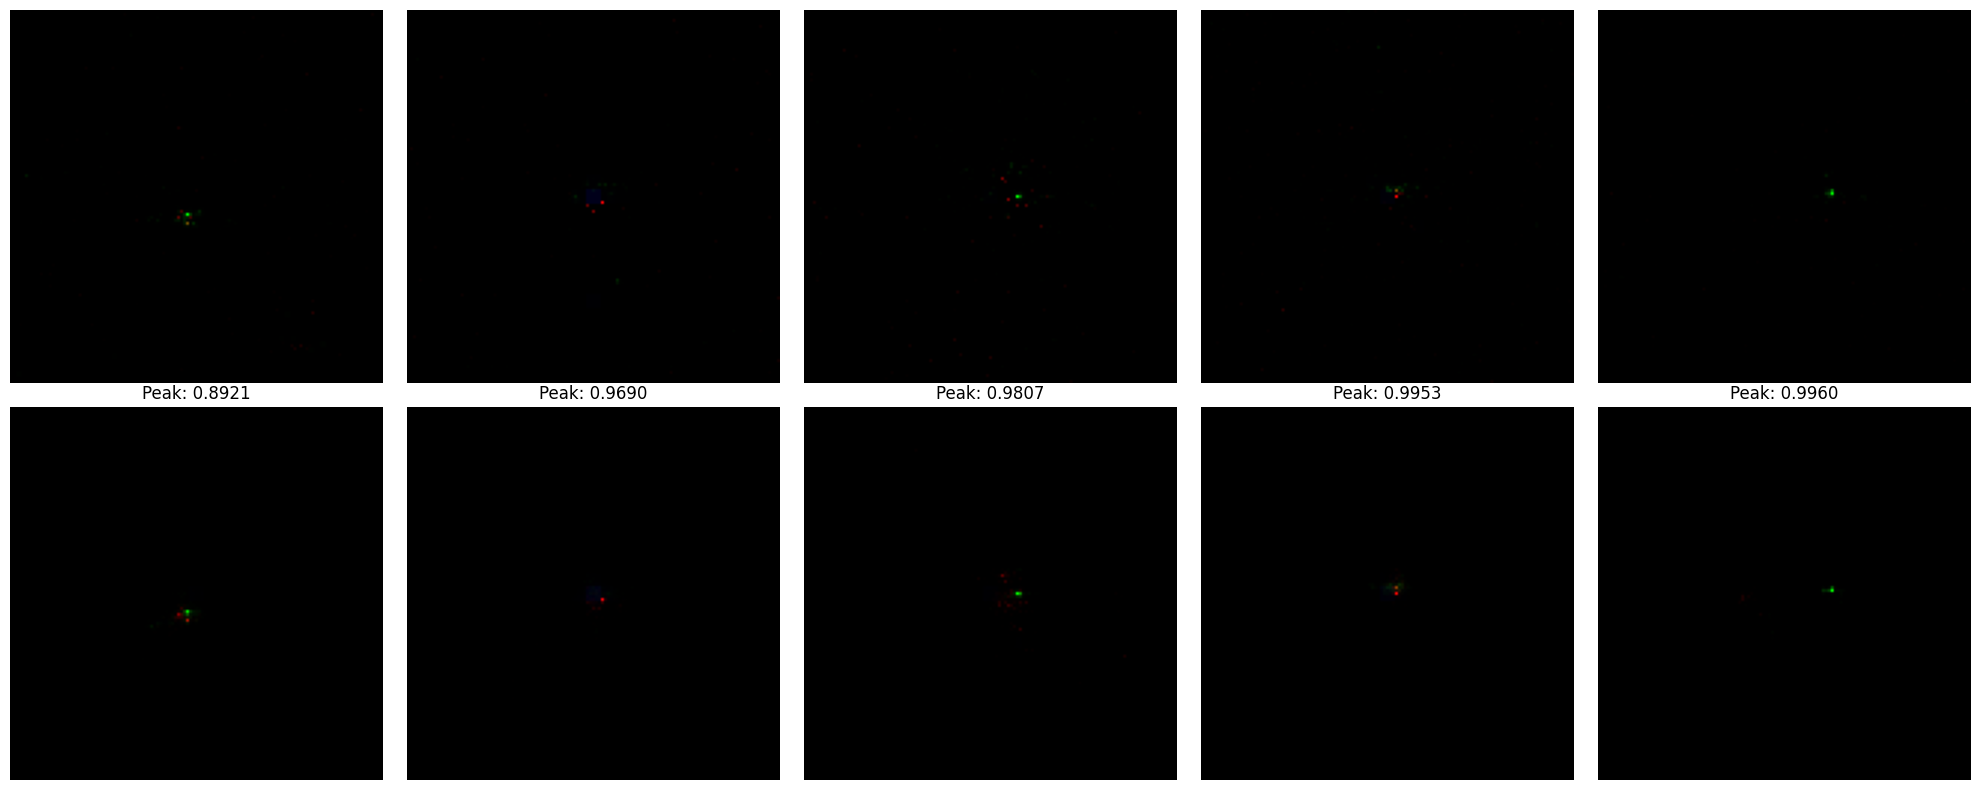

Epoch 810 | Train Loss 2.954 | Val Loss 77.660 | 23.5s
Step [100/123] | Loss: 2.8847 | Beta: 0.010
Epoch 811 | Train Loss 2.953 | Val Loss 77.884 | 22.9s
Step [100/123] | Loss: 2.8102 | Beta: 0.010
Epoch 812 | Train Loss 2.950 | Val Loss 77.636 | 23.0s
Step [100/123] | Loss: 2.9574 | Beta: 0.010
Epoch 813 | Train Loss 2.946 | Val Loss 76.962 | 23.3s
Step [100/123] | Loss: 2.9546 | Beta: 0.010
Epoch 814 | Train Loss 2.945 | Val Loss 77.227 | 23.5s
Step [100/123] | Loss: 2.8686 | Beta: 0.010
Epoch 815 | Train Loss 2.944 | Val Loss 76.392 | 22.9s
Step [100/123] | Loss: 2.7865 | Beta: 0.010
Epoch 816 | Train Loss 2.940 | Val Loss 75.569 | 23.5s
Step [100/123] | Loss: 2.9258 | Beta: 0.010
Epoch 817 | Train Loss 2.940 | Val Loss 77.153 | 23.6s
Step [100/123] | Loss: 2.8644 | Beta: 0.010
Epoch 818 | Train Loss 2.936 | Val Loss 77.423 | 23.3s
Step [100/123] | Loss: 2.9773 | Beta: 0.010
Epoch 819 | Train Loss 2.936 | Val Loss 76.296 | 23.4s
Step [100/123] | Loss: 2.7852 | Beta: 0.010
--- DEBUG 

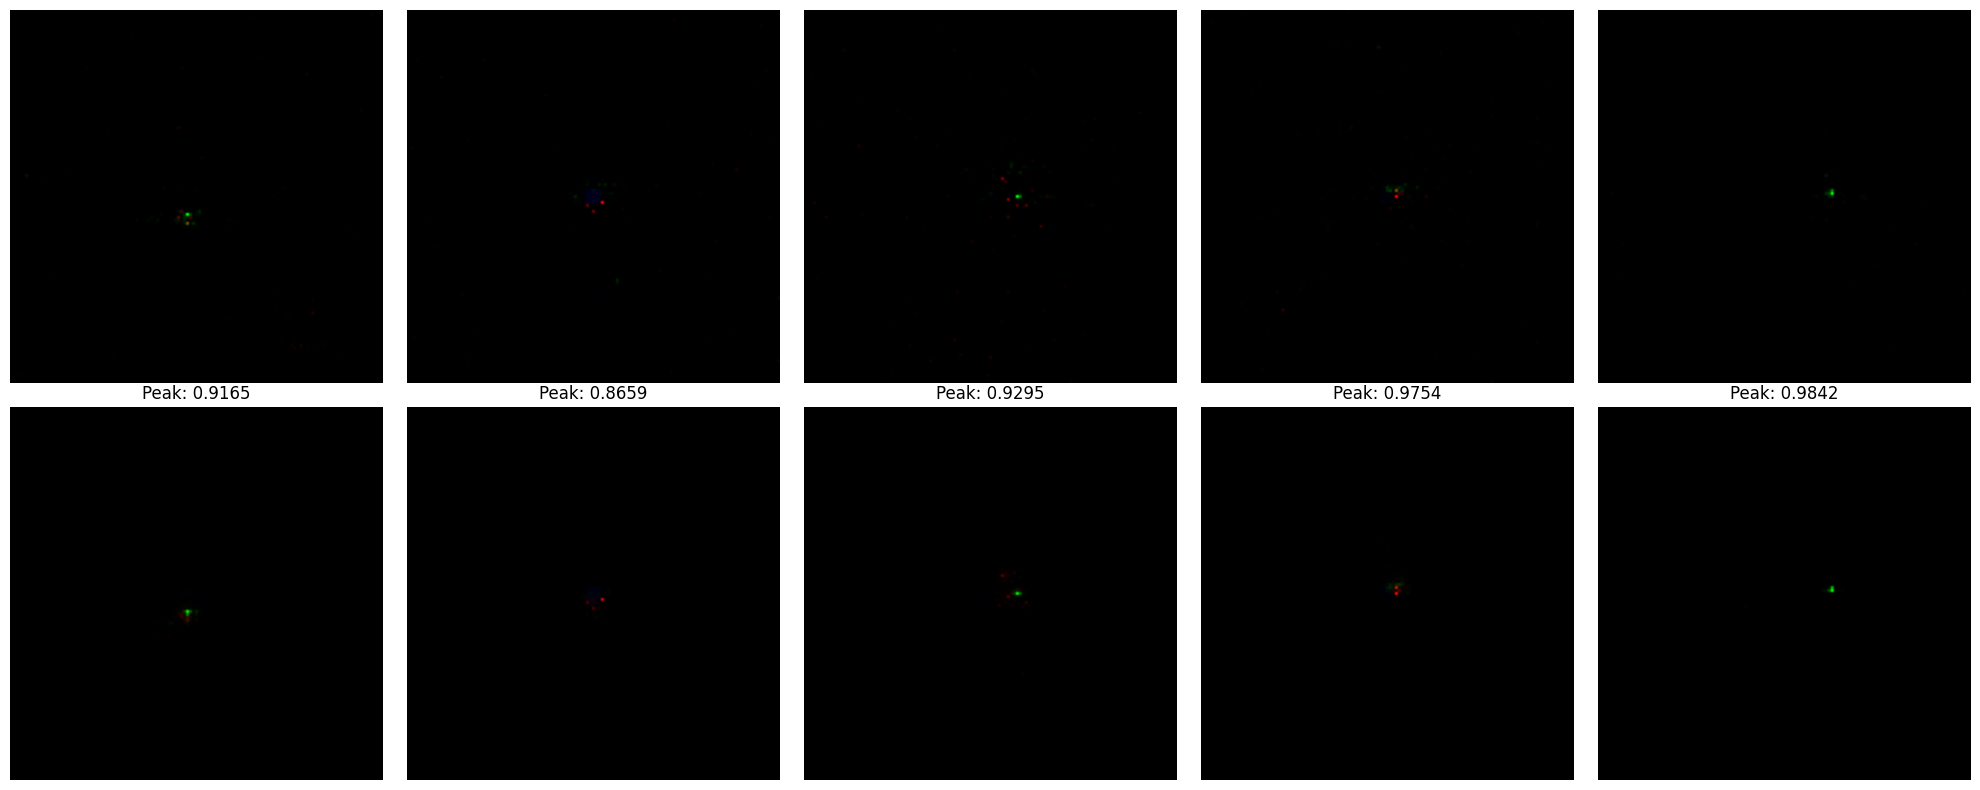

Epoch 820 | Train Loss 2.933 | Val Loss 76.510 | 24.2s
Step [100/123] | Loss: 2.9584 | Beta: 0.010
Epoch 821 | Train Loss 2.933 | Val Loss 76.603 | 23.5s
Step [100/123] | Loss: 2.9130 | Beta: 0.010
Epoch 822 | Train Loss 2.930 | Val Loss 75.650 | 23.2s
Step [100/123] | Loss: 2.9399 | Beta: 0.010
Epoch 823 | Train Loss 2.930 | Val Loss 77.203 | 23.1s
Step [100/123] | Loss: 2.8456 | Beta: 0.010
Epoch 824 | Train Loss 2.927 | Val Loss 77.198 | 23.1s
Step [100/123] | Loss: 2.9157 | Beta: 0.010
Epoch 825 | Train Loss 2.926 | Val Loss 76.905 | 23.4s
Step [100/123] | Loss: 2.8218 | Beta: 0.010
Epoch 826 | Train Loss 2.924 | Val Loss 77.028 | 23.6s
Step [100/123] | Loss: 2.8942 | Beta: 0.010
Epoch 827 | Train Loss 2.923 | Val Loss 76.532 | 23.4s
Step [100/123] | Loss: 2.8732 | Beta: 0.010
Epoch 828 | Train Loss 2.922 | Val Loss 76.991 | 23.2s
Step [100/123] | Loss: 2.8178 | Beta: 0.010
Epoch 829 | Train Loss 2.920 | Val Loss 76.617 | 23.3s
Step [100/123] | Loss: 2.9087 | Beta: 0.010
--- DEBUG 

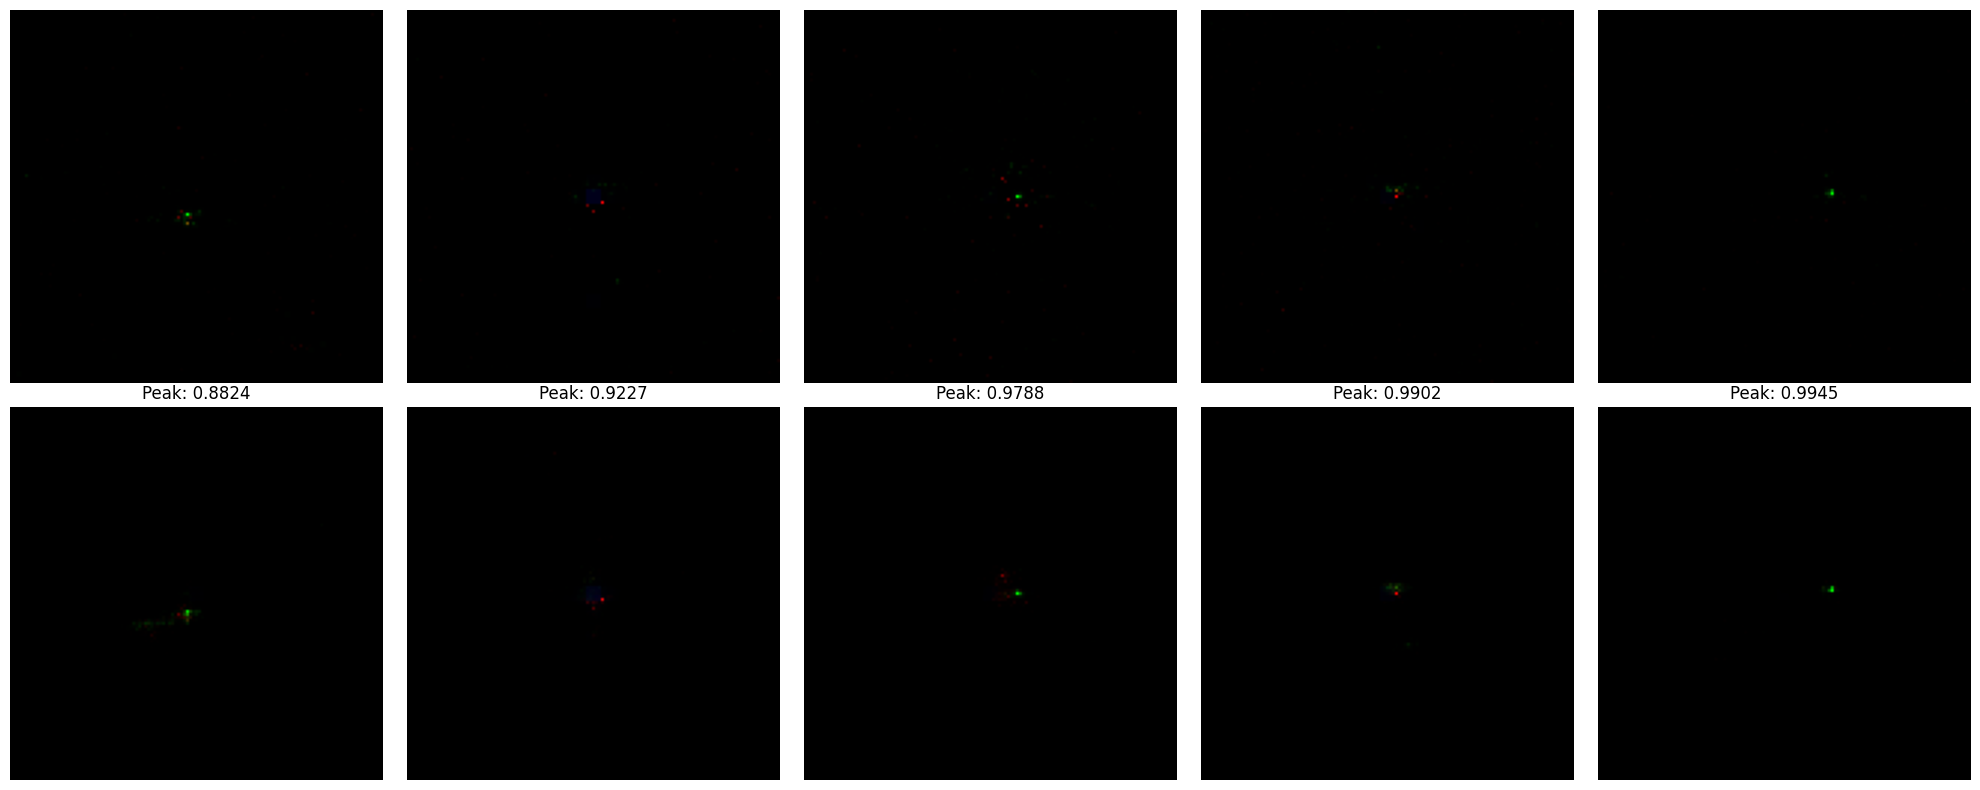

Epoch 830 | Train Loss 2.919 | Val Loss 75.899 | 23.8s
Step [100/123] | Loss: 2.7911 | Beta: 0.010
Epoch 831 | Train Loss 2.919 | Val Loss 75.887 | 23.1s
Step [100/123] | Loss: 2.8467 | Beta: 0.010
Epoch 832 | Train Loss 2.916 | Val Loss 77.663 | 23.2s
Step [100/123] | Loss: 2.9091 | Beta: 0.010
Epoch 833 | Train Loss 2.915 | Val Loss 76.150 | 23.2s
Step [100/123] | Loss: 2.9776 | Beta: 0.010
Epoch 834 | Train Loss 2.915 | Val Loss 76.083 | 23.2s
Step [100/123] | Loss: 2.9069 | Beta: 0.010
Epoch 835 | Train Loss 2.914 | Val Loss 77.216 | 23.2s
Step [100/123] | Loss: 2.8609 | Beta: 0.010
Epoch 836 | Train Loss 2.911 | Val Loss 76.286 | 23.1s
Step [100/123] | Loss: 2.7885 | Beta: 0.010
Epoch 837 | Train Loss 2.911 | Val Loss 77.487 | 23.4s
Step [100/123] | Loss: 2.9645 | Beta: 0.010
Epoch 838 | Train Loss 2.909 | Val Loss 76.728 | 23.0s
Step [100/123] | Loss: 3.0357 | Beta: 0.010
Epoch 839 | Train Loss 2.907 | Val Loss 76.495 | 22.9s
Step [100/123] | Loss: 3.0125 | Beta: 0.010
--- DEBUG 

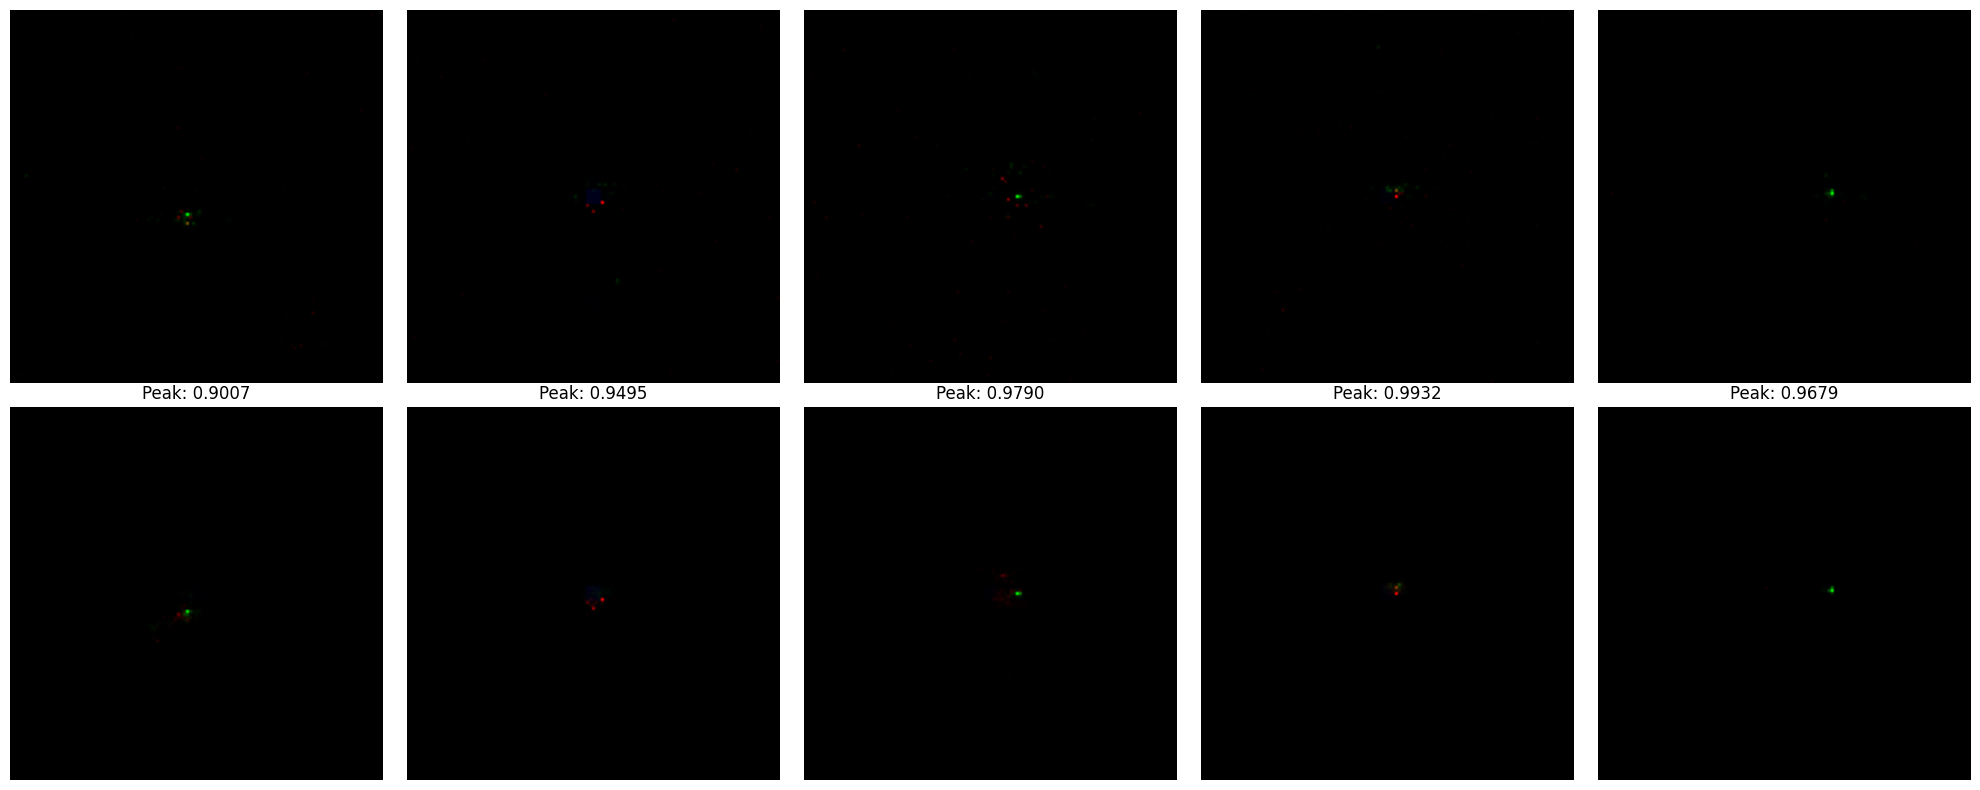

Epoch 840 | Train Loss 2.907 | Val Loss 77.458 | 23.7s
Step [100/123] | Loss: 2.8435 | Beta: 0.010
Epoch 841 | Train Loss 2.905 | Val Loss 77.498 | 22.9s
Step [100/123] | Loss: 2.9979 | Beta: 0.010
Epoch 842 | Train Loss 2.905 | Val Loss 76.785 | 23.1s
Step [100/123] | Loss: 3.0577 | Beta: 0.010
Epoch 843 | Train Loss 2.903 | Val Loss 77.620 | 22.4s
Step [100/123] | Loss: 2.7961 | Beta: 0.010
Epoch 844 | Train Loss 2.901 | Val Loss 76.831 | 23.2s
Step [100/123] | Loss: 2.9573 | Beta: 0.010
Epoch 845 | Train Loss 2.901 | Val Loss 76.319 | 22.9s
Step [100/123] | Loss: 3.0084 | Beta: 0.010
Epoch 846 | Train Loss 2.902 | Val Loss 76.332 | 22.7s
Step [100/123] | Loss: 2.8607 | Beta: 0.010
Epoch 847 | Train Loss 2.899 | Val Loss 77.777 | 22.8s
Step [100/123] | Loss: 2.9052 | Beta: 0.010
Epoch 848 | Train Loss 2.896 | Val Loss 77.158 | 22.9s
Step [100/123] | Loss: 2.6436 | Beta: 0.010
Epoch 849 | Train Loss 2.896 | Val Loss 78.062 | 23.3s
Step [100/123] | Loss: 2.9259 | Beta: 0.010
--- DEBUG 

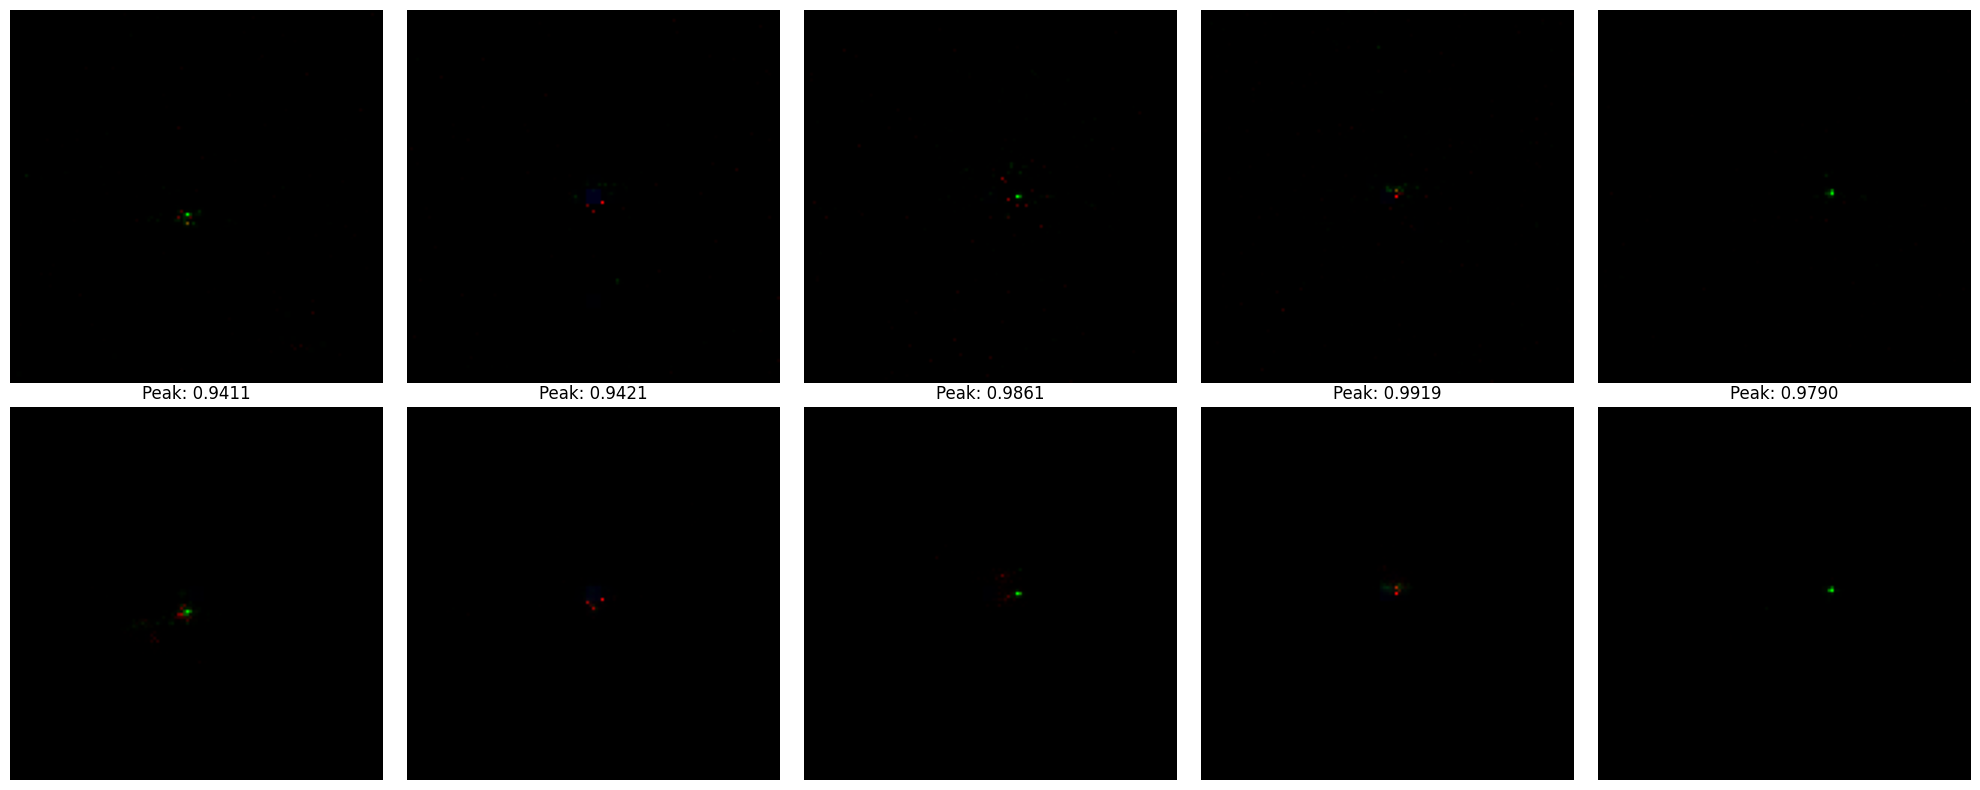

Epoch 850 | Train Loss 2.895 | Val Loss 76.537 | 23.6s
Step [100/123] | Loss: 2.8240 | Beta: 0.010
Epoch 851 | Train Loss 2.894 | Val Loss 77.407 | 23.1s
Step [100/123] | Loss: 3.0092 | Beta: 0.010
Epoch 852 | Train Loss 2.893 | Val Loss 76.220 | 23.1s
Step [100/123] | Loss: 2.7322 | Beta: 0.010
Epoch 853 | Train Loss 2.894 | Val Loss 78.050 | 23.0s
Step [100/123] | Loss: 2.8397 | Beta: 0.010
Epoch 854 | Train Loss 2.892 | Val Loss 76.983 | 23.1s
Step [100/123] | Loss: 2.8602 | Beta: 0.010
Epoch 855 | Train Loss 2.890 | Val Loss 75.837 | 23.1s
Step [100/123] | Loss: 2.9472 | Beta: 0.010
Epoch 856 | Train Loss 2.891 | Val Loss 77.055 | 23.1s
Step [100/123] | Loss: 2.9665 | Beta: 0.010
Epoch 857 | Train Loss 2.886 | Val Loss 78.256 | 22.9s
Step [100/123] | Loss: 2.8638 | Beta: 0.010
Epoch 858 | Train Loss 2.889 | Val Loss 76.248 | 22.9s
Step [100/123] | Loss: 2.8218 | Beta: 0.010
Epoch 859 | Train Loss 2.886 | Val Loss 76.570 | 22.9s
Step [100/123] | Loss: 2.8573 | Beta: 0.010
--- DEBUG 

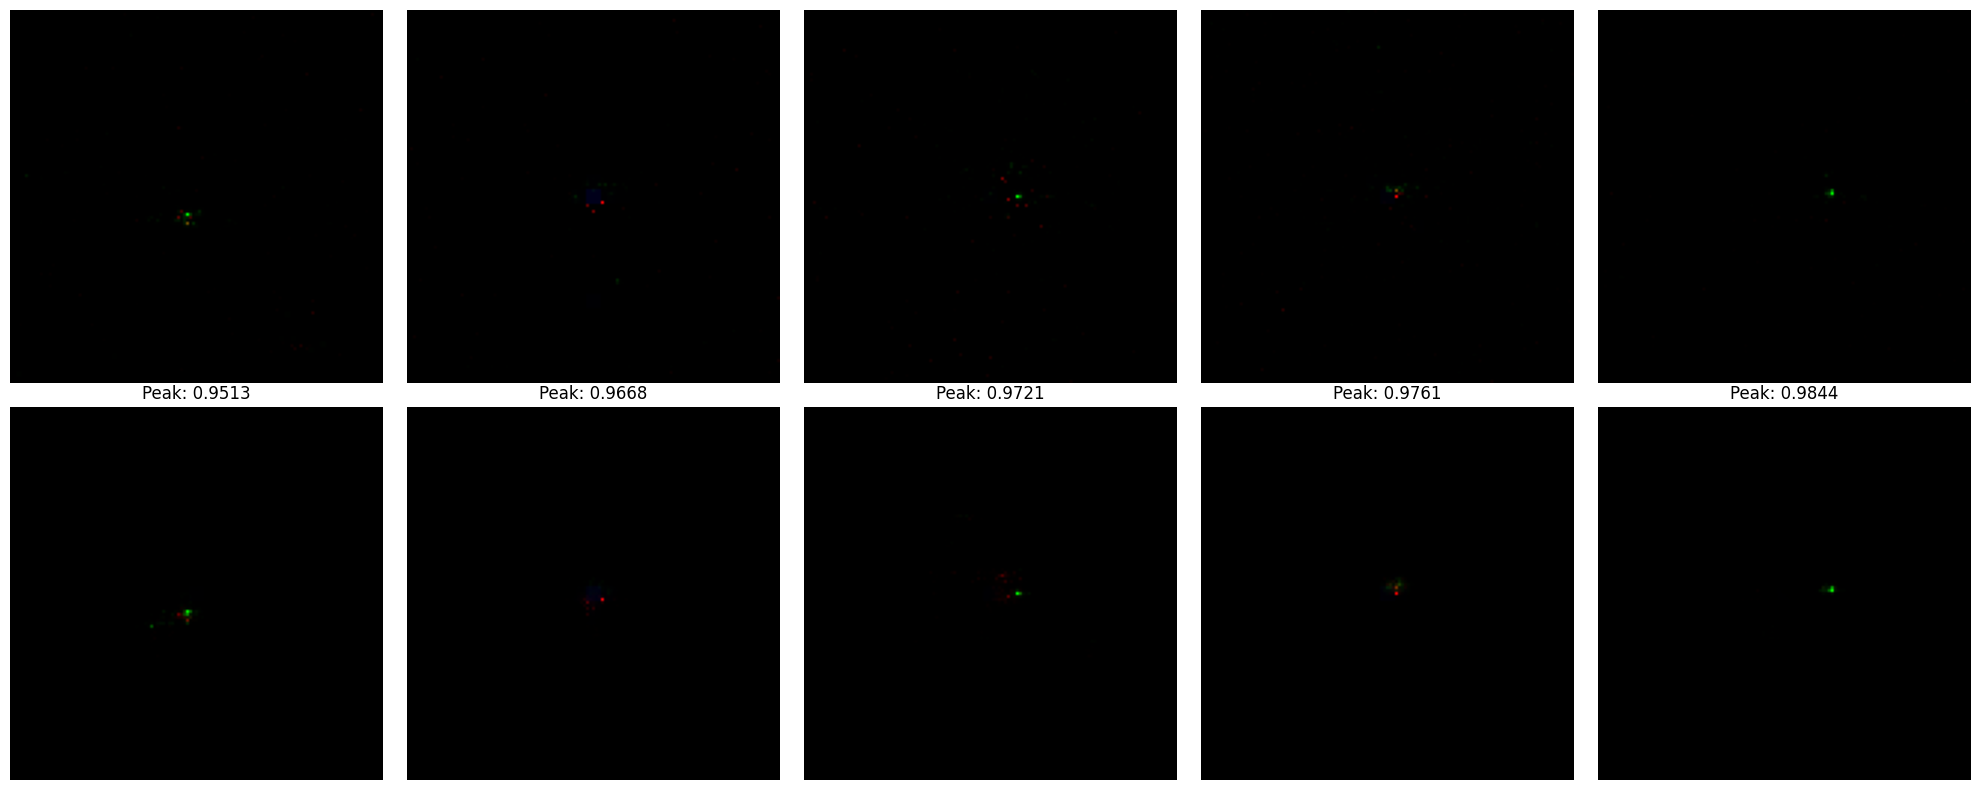

Epoch 860 | Train Loss 2.885 | Val Loss 77.451 | 23.7s
Step [100/123] | Loss: 3.0261 | Beta: 0.010
Epoch 861 | Train Loss 2.886 | Val Loss 77.988 | 22.7s
Step [100/123] | Loss: 2.8721 | Beta: 0.010
Epoch 862 | Train Loss 2.886 | Val Loss 76.951 | 22.8s
Step [100/123] | Loss: 2.7305 | Beta: 0.010
Epoch 863 | Train Loss 2.883 | Val Loss 78.237 | 22.7s
Step [100/123] | Loss: 2.7789 | Beta: 0.010
Epoch 864 | Train Loss 2.882 | Val Loss 77.802 | 22.8s
Step [100/123] | Loss: 2.8363 | Beta: 0.010
Epoch 865 | Train Loss 2.880 | Val Loss 78.383 | 22.9s
Step [100/123] | Loss: 2.8800 | Beta: 0.010
Epoch 866 | Train Loss 2.879 | Val Loss 76.940 | 22.7s
Step [100/123] | Loss: 2.9064 | Beta: 0.010
Epoch 867 | Train Loss 2.879 | Val Loss 78.016 | 22.7s
Step [100/123] | Loss: 2.9622 | Beta: 0.010
Epoch 868 | Train Loss 2.878 | Val Loss 77.034 | 23.1s
Step [100/123] | Loss: 2.9725 | Beta: 0.010
Epoch 869 | Train Loss 2.878 | Val Loss 77.617 | 22.8s
Step [100/123] | Loss: 2.9475 | Beta: 0.010
--- DEBUG 

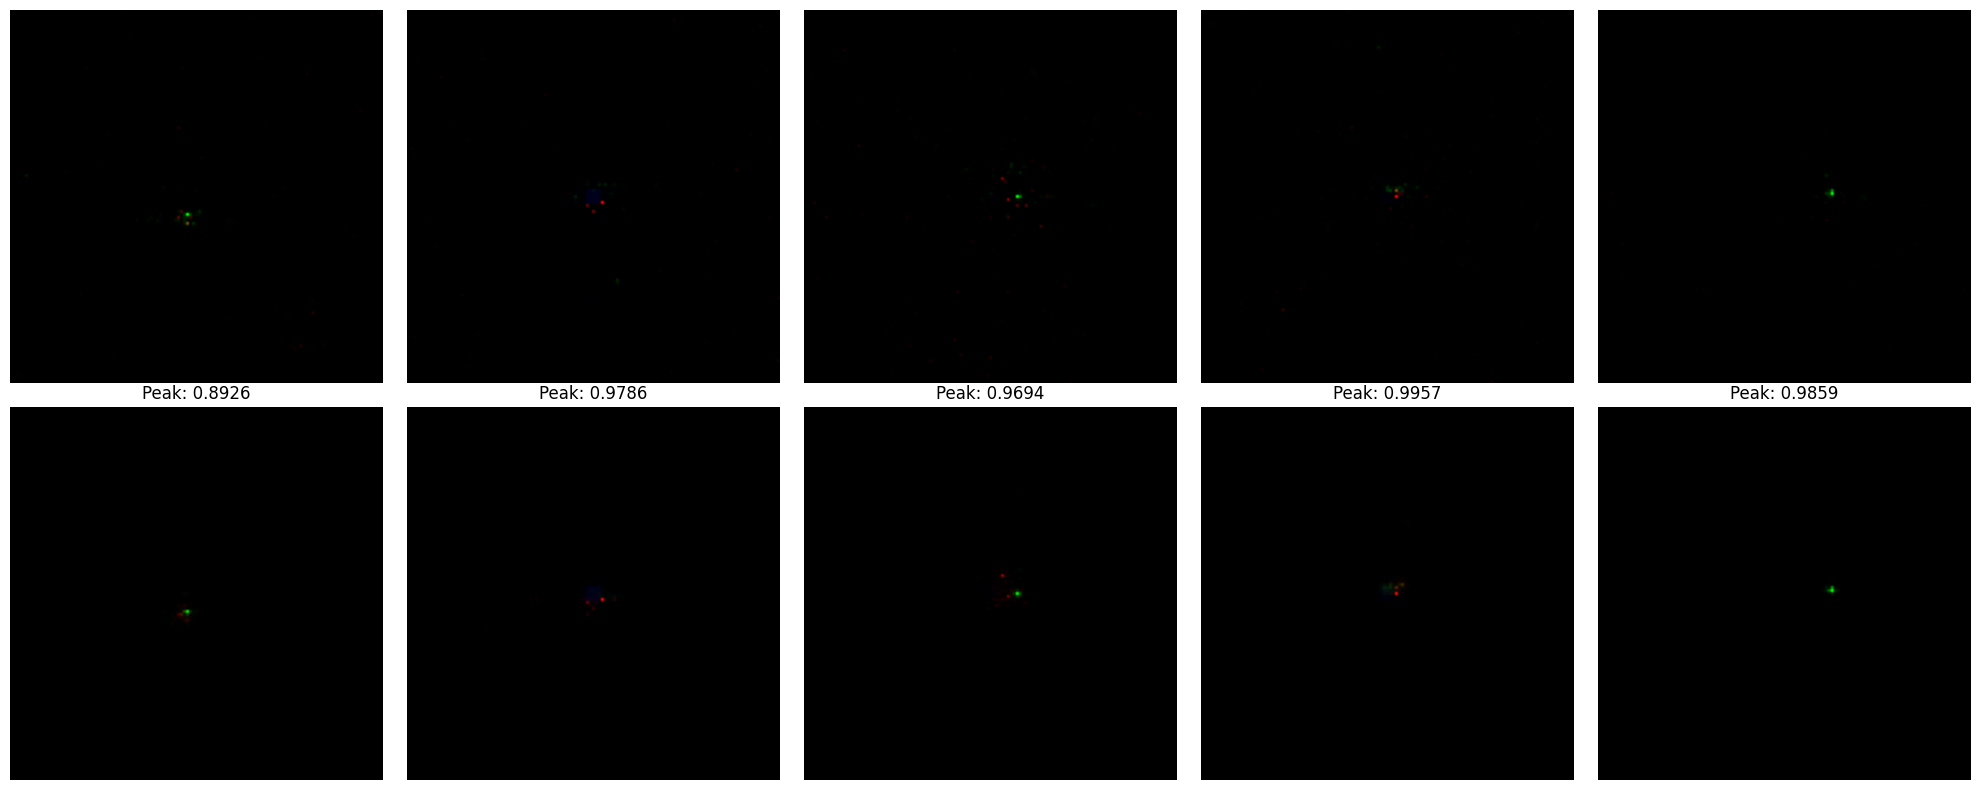

Epoch 870 | Train Loss 2.877 | Val Loss 77.739 | 23.4s
Step [100/123] | Loss: 2.9057 | Beta: 0.010
Epoch 871 | Train Loss 2.876 | Val Loss 78.151 | 23.0s
Step [100/123] | Loss: 2.8442 | Beta: 0.010
Epoch 872 | Train Loss 2.874 | Val Loss 77.221 | 22.9s
Step [100/123] | Loss: 2.9343 | Beta: 0.010
Epoch 873 | Train Loss 2.874 | Val Loss 76.537 | 22.8s
Step [100/123] | Loss: 2.7380 | Beta: 0.010
Epoch 874 | Train Loss 2.873 | Val Loss 78.186 | 22.8s
Step [100/123] | Loss: 2.8333 | Beta: 0.010
Epoch 875 | Train Loss 2.870 | Val Loss 77.417 | 22.8s
Step [100/123] | Loss: 2.9303 | Beta: 0.010
Epoch 876 | Train Loss 2.871 | Val Loss 76.651 | 22.8s
Step [100/123] | Loss: 2.9339 | Beta: 0.010
Epoch 877 | Train Loss 2.870 | Val Loss 77.569 | 23.0s
Step [100/123] | Loss: 2.8003 | Beta: 0.010
Epoch 878 | Train Loss 2.870 | Val Loss 75.560 | 23.0s
Step [100/123] | Loss: 2.7729 | Beta: 0.010
Epoch 879 | Train Loss 2.871 | Val Loss 76.475 | 22.7s
Step [100/123] | Loss: 2.9401 | Beta: 0.010
--- DEBUG 

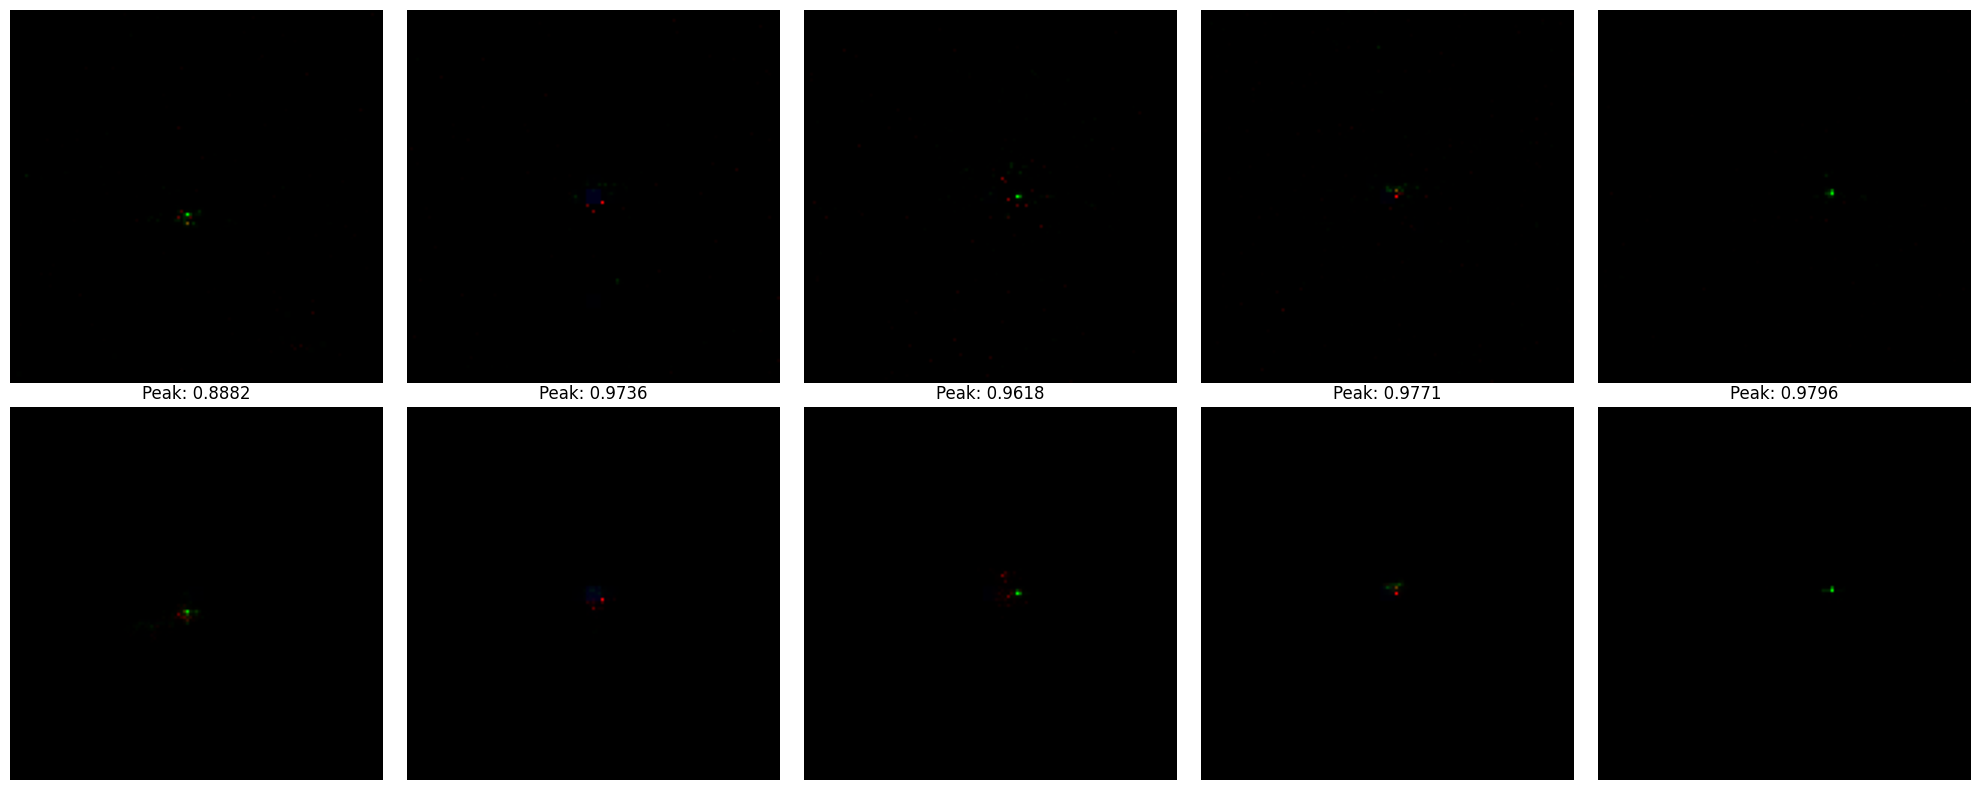

Epoch 880 | Train Loss 2.868 | Val Loss 76.302 | 23.6s
Step [100/123] | Loss: 2.8944 | Beta: 0.010
Epoch 881 | Train Loss 2.867 | Val Loss 78.612 | 22.8s
Step [100/123] | Loss: 2.6965 | Beta: 0.010
Epoch 882 | Train Loss 2.868 | Val Loss 76.990 | 22.9s
Step [100/123] | Loss: 3.0019 | Beta: 0.010
Epoch 883 | Train Loss 2.863 | Val Loss 77.295 | 22.7s
Step [100/123] | Loss: 2.7824 | Beta: 0.010
Epoch 884 | Train Loss 2.862 | Val Loss 77.178 | 22.9s
Step [100/123] | Loss: 2.8601 | Beta: 0.010
Epoch 885 | Train Loss 2.863 | Val Loss 77.420 | 22.7s
Step [100/123] | Loss: 2.8228 | Beta: 0.010
Epoch 886 | Train Loss 2.862 | Val Loss 76.678 | 22.9s
Step [100/123] | Loss: 2.9558 | Beta: 0.010
Epoch 887 | Train Loss 2.862 | Val Loss 76.002 | 22.8s
Step [100/123] | Loss: 2.8595 | Beta: 0.010
Epoch 888 | Train Loss 2.860 | Val Loss 79.238 | 22.9s
Step [100/123] | Loss: 2.8911 | Beta: 0.010
Epoch 889 | Train Loss 2.861 | Val Loss 77.446 | 22.8s
Step [100/123] | Loss: 3.0133 | Beta: 0.010
--- DEBUG 

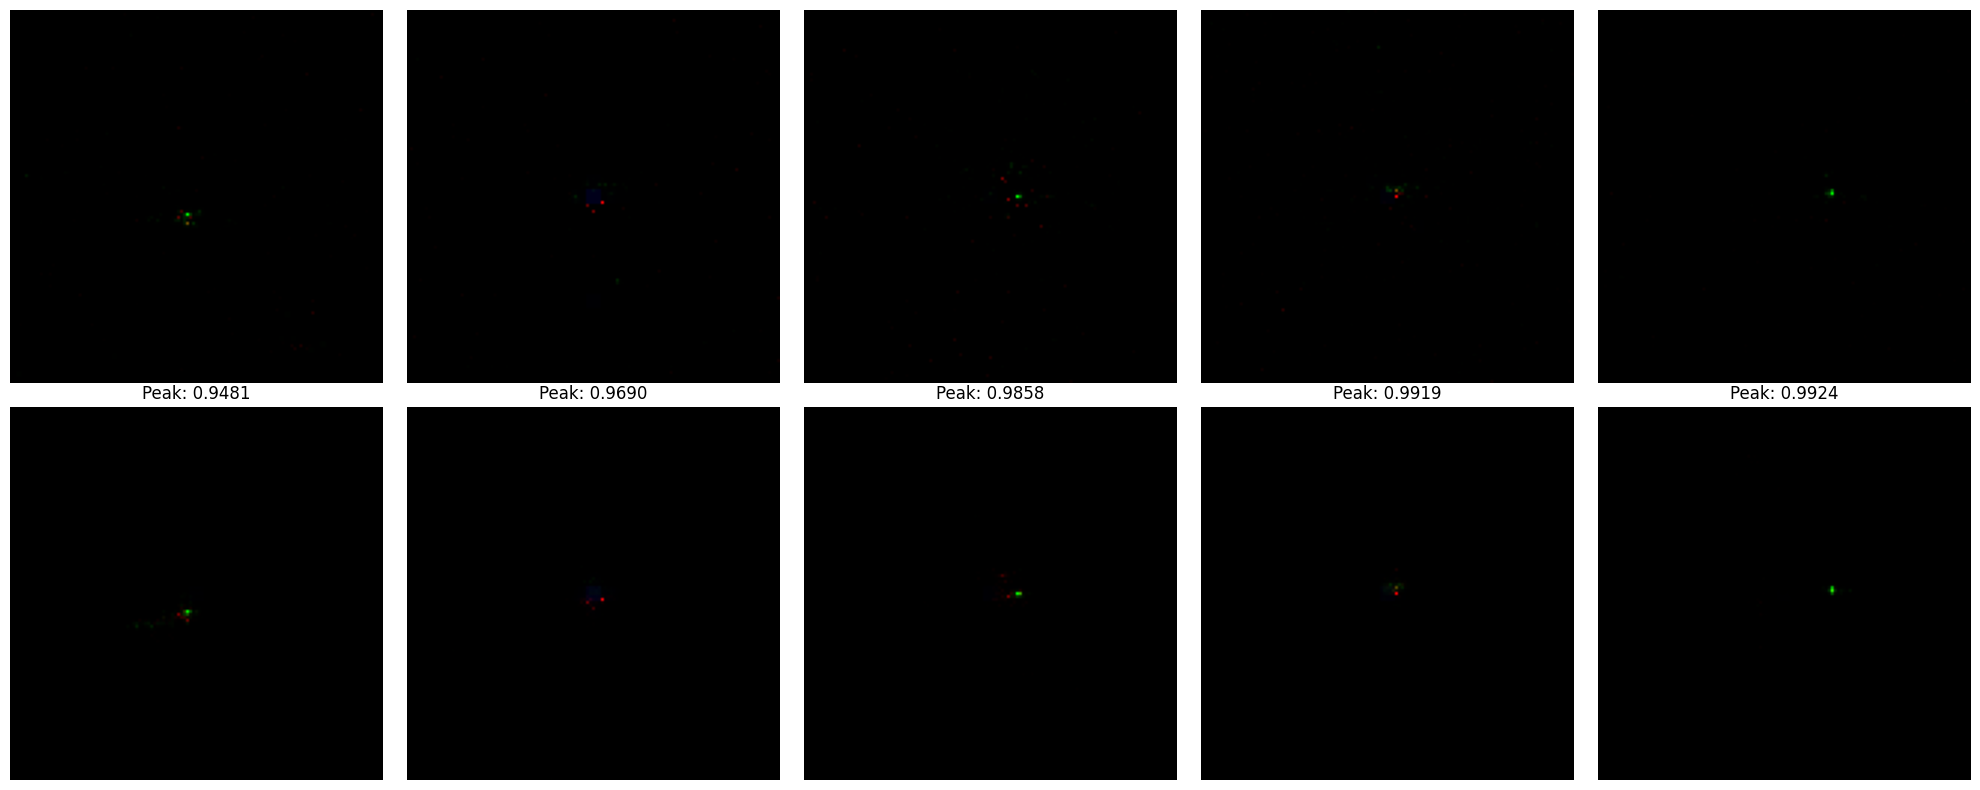

Epoch 890 | Train Loss 2.859 | Val Loss 76.311 | 23.2s
Step [100/123] | Loss: 2.7790 | Beta: 0.010
Epoch 891 | Train Loss 2.858 | Val Loss 76.223 | 22.9s
Step [100/123] | Loss: 2.9182 | Beta: 0.010
Epoch 892 | Train Loss 2.857 | Val Loss 77.609 | 22.7s
Step [100/123] | Loss: 2.8525 | Beta: 0.010
Epoch 893 | Train Loss 2.859 | Val Loss 76.552 | 22.7s
Step [100/123] | Loss: 3.0541 | Beta: 0.010
Epoch 894 | Train Loss 2.855 | Val Loss 76.552 | 22.5s
Step [100/123] | Loss: 3.1752 | Beta: 0.010
Epoch 895 | Train Loss 2.857 | Val Loss 77.805 | 22.7s
Step [100/123] | Loss: 2.8814 | Beta: 0.010
Epoch 896 | Train Loss 2.853 | Val Loss 77.024 | 22.6s
Step [100/123] | Loss: 2.8555 | Beta: 0.010
Epoch 897 | Train Loss 2.855 | Val Loss 77.709 | 22.7s
Step [100/123] | Loss: 2.9546 | Beta: 0.010
Epoch 898 | Train Loss 2.854 | Val Loss 78.874 | 22.8s
Step [100/123] | Loss: 2.8749 | Beta: 0.010
Epoch 899 | Train Loss 2.853 | Val Loss 76.265 | 22.8s
Step [100/123] | Loss: 2.8804 | Beta: 0.010
--- DEBUG 

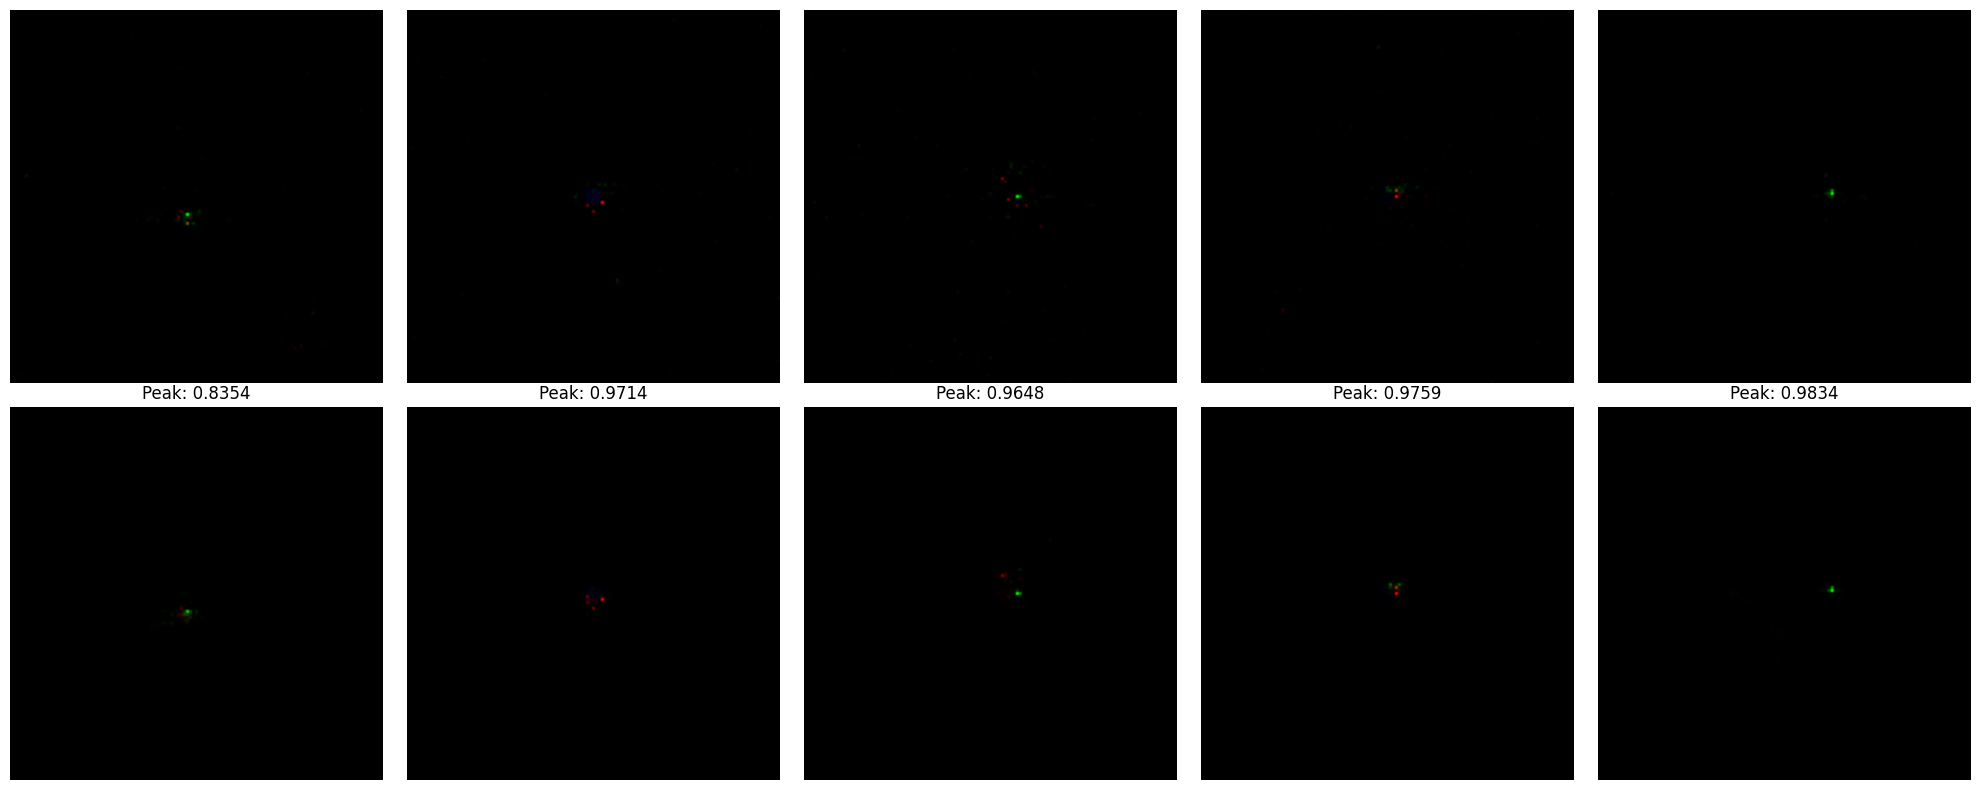

Epoch 900 | Train Loss 2.850 | Val Loss 77.326 | 23.6s
Step [100/123] | Loss: 2.9370 | Beta: 0.010
Epoch 901 | Train Loss 2.851 | Val Loss 77.763 | 22.9s
Step [100/123] | Loss: 2.9104 | Beta: 0.010
Epoch 902 | Train Loss 2.848 | Val Loss 77.336 | 22.9s
Step [100/123] | Loss: 2.7288 | Beta: 0.010
Epoch 903 | Train Loss 2.849 | Val Loss 78.008 | 22.8s
Step [100/123] | Loss: 2.8799 | Beta: 0.010
Epoch 904 | Train Loss 2.847 | Val Loss 77.632 | 22.9s
Step [100/123] | Loss: 2.9325 | Beta: 0.010
Epoch 905 | Train Loss 2.849 | Val Loss 78.009 | 22.9s
Step [100/123] | Loss: 2.6159 | Beta: 0.010
Epoch 906 | Train Loss 2.849 | Val Loss 78.430 | 22.8s
Step [100/123] | Loss: 2.7073 | Beta: 0.010
Epoch 907 | Train Loss 2.845 | Val Loss 78.300 | 22.9s
Step [100/123] | Loss: 2.8384 | Beta: 0.010
Epoch 908 | Train Loss 2.844 | Val Loss 77.964 | 23.0s
Step [100/123] | Loss: 2.8072 | Beta: 0.010
Epoch 909 | Train Loss 2.845 | Val Loss 76.515 | 22.7s
Step [100/123] | Loss: 2.7518 | Beta: 0.010
--- DEBUG 

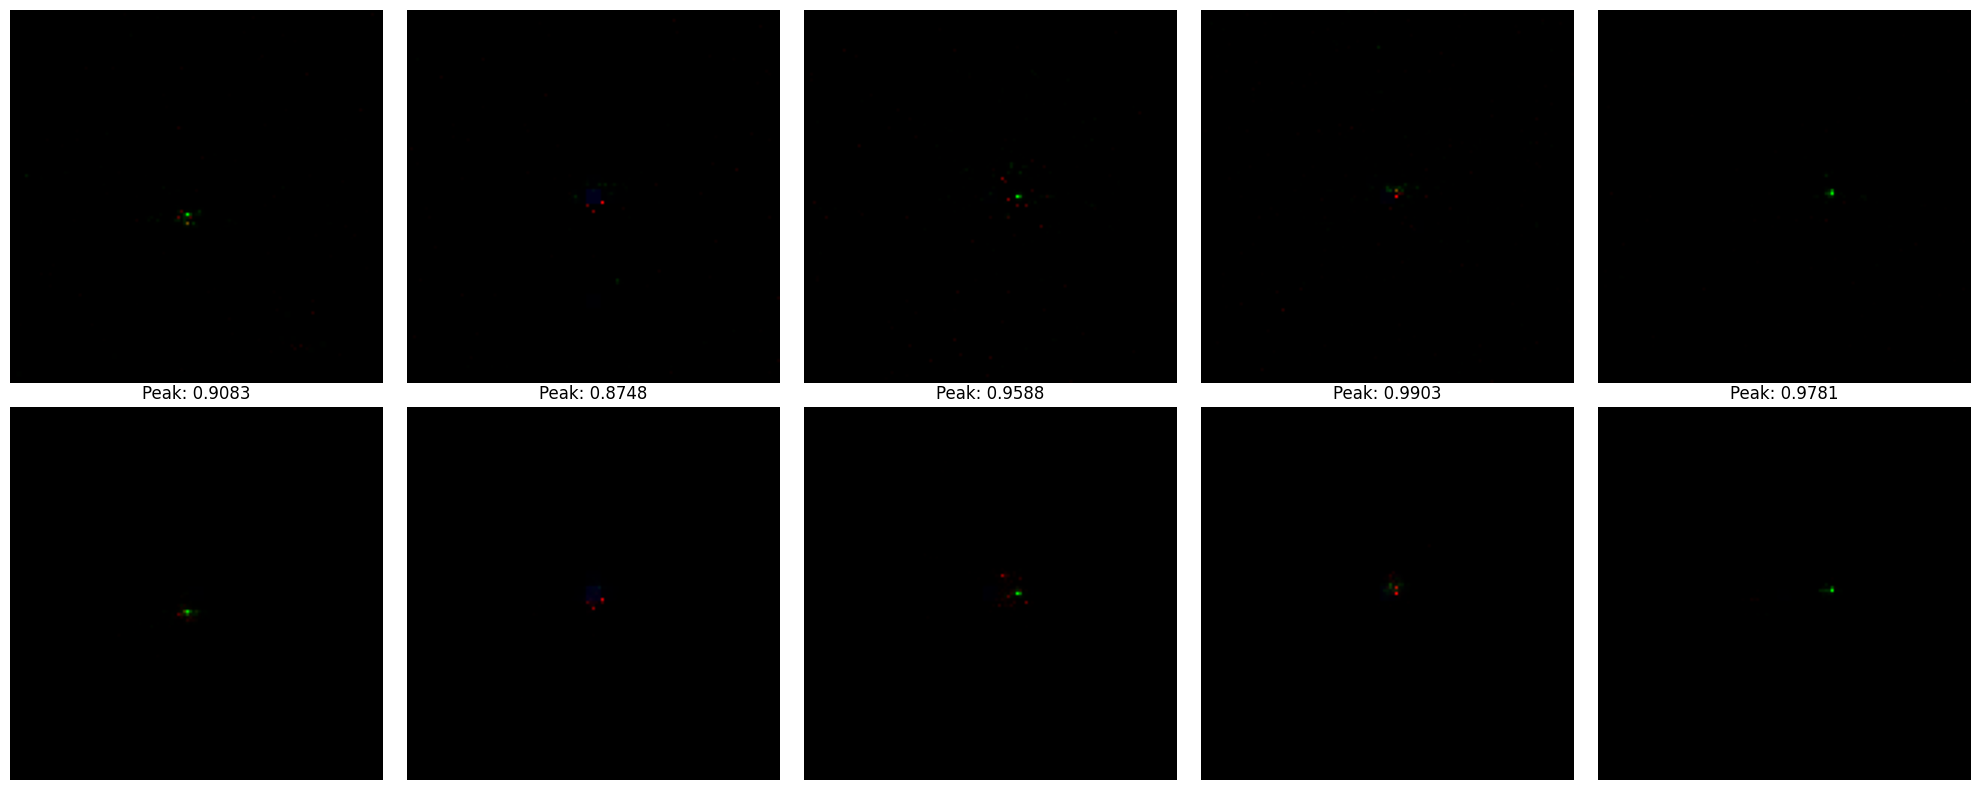

Epoch 910 | Train Loss 2.843 | Val Loss 76.917 | 23.4s
Step [100/123] | Loss: 3.0536 | Beta: 0.010
Epoch 911 | Train Loss 2.844 | Val Loss 76.425 | 22.7s
Step [100/123] | Loss: 2.7554 | Beta: 0.010
Epoch 912 | Train Loss 2.841 | Val Loss 76.730 | 22.9s
Step [100/123] | Loss: 2.8704 | Beta: 0.010
Epoch 913 | Train Loss 2.840 | Val Loss 77.992 | 22.9s
Step [100/123] | Loss: 2.9151 | Beta: 0.010
Epoch 914 | Train Loss 2.841 | Val Loss 77.101 | 23.6s
Step [100/123] | Loss: 2.7184 | Beta: 0.010
Epoch 915 | Train Loss 2.840 | Val Loss 76.323 | 23.2s
Step [100/123] | Loss: 2.8357 | Beta: 0.010
Epoch 916 | Train Loss 2.840 | Val Loss 76.425 | 23.1s
Step [100/123] | Loss: 2.9965 | Beta: 0.010
Epoch 917 | Train Loss 2.838 | Val Loss 77.693 | 23.0s
Step [100/123] | Loss: 2.8645 | Beta: 0.010
Epoch 918 | Train Loss 2.839 | Val Loss 77.808 | 23.0s
Step [100/123] | Loss: 3.0280 | Beta: 0.010
Epoch 919 | Train Loss 2.839 | Val Loss 78.515 | 23.0s
Step [100/123] | Loss: 2.9296 | Beta: 0.010
--- DEBUG 

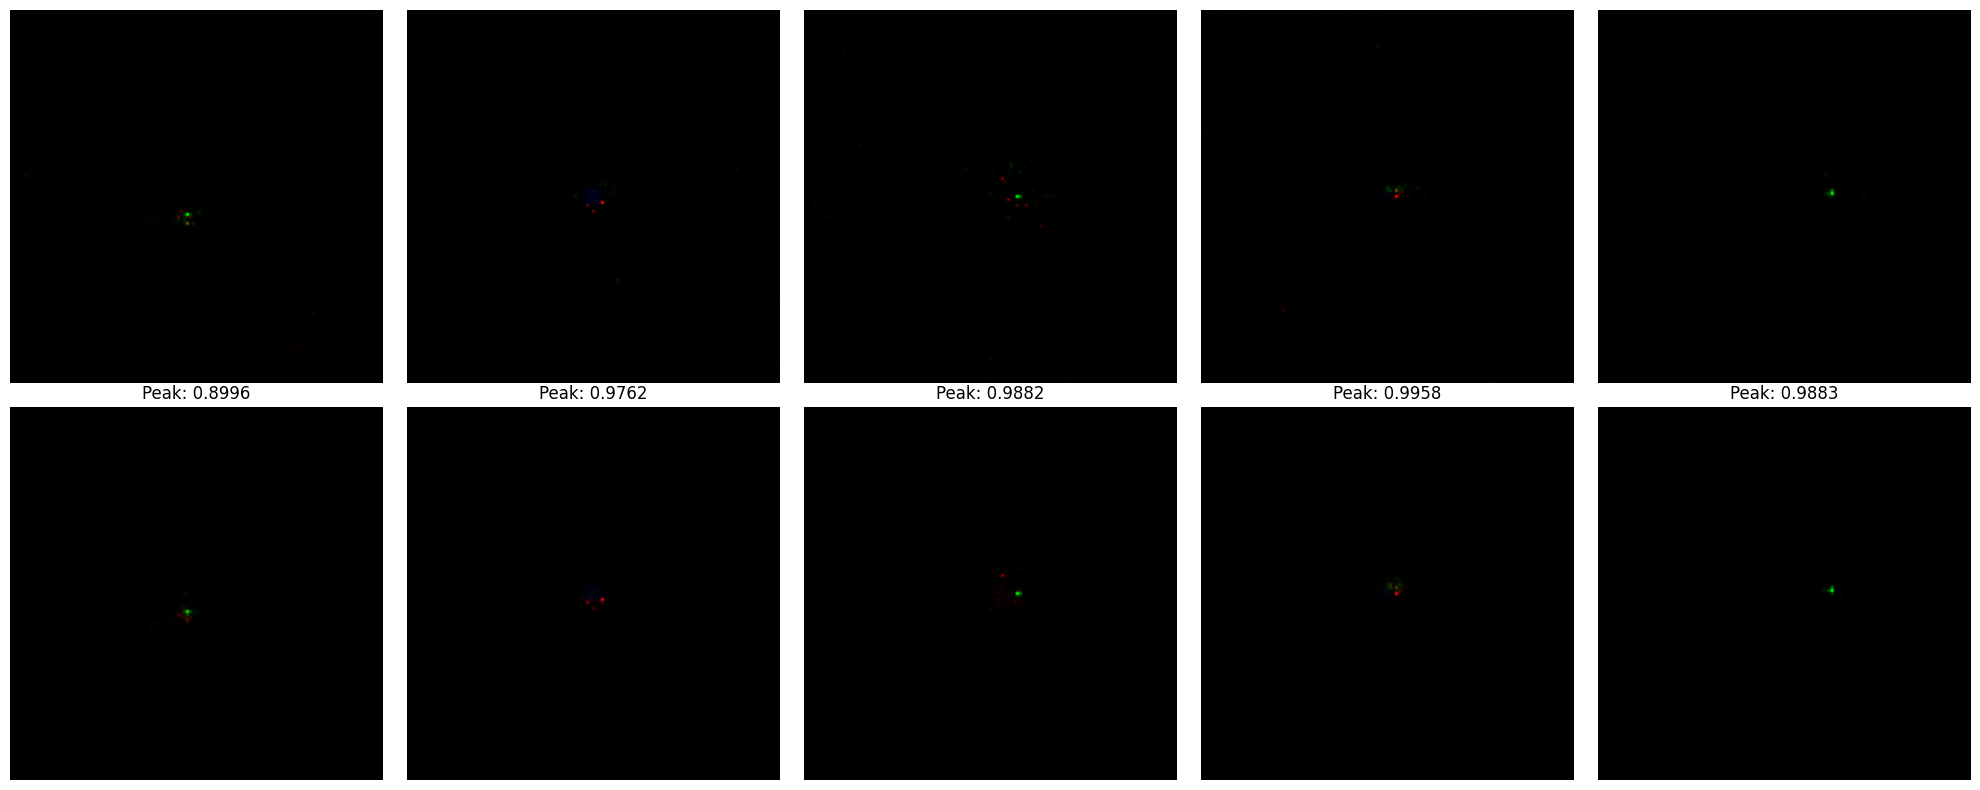

Epoch 920 | Train Loss 2.837 | Val Loss 77.504 | 23.8s
Step [100/123] | Loss: 2.9016 | Beta: 0.010
Epoch 921 | Train Loss 2.837 | Val Loss 77.852 | 23.2s
Step [100/123] | Loss: 2.6894 | Beta: 0.010
Epoch 922 | Train Loss 2.836 | Val Loss 77.009 | 23.1s
Step [100/123] | Loss: 2.8982 | Beta: 0.010
Epoch 923 | Train Loss 2.836 | Val Loss 78.522 | 23.1s
Step [100/123] | Loss: 2.9062 | Beta: 0.010
Epoch 924 | Train Loss 2.833 | Val Loss 78.166 | 23.3s
Step [100/123] | Loss: 2.8962 | Beta: 0.010
Epoch 925 | Train Loss 2.834 | Val Loss 77.139 | 22.9s
Step [100/123] | Loss: 2.7449 | Beta: 0.010
Epoch 926 | Train Loss 2.831 | Val Loss 78.587 | 22.9s
Step [100/123] | Loss: 2.7087 | Beta: 0.010
Epoch 927 | Train Loss 2.830 | Val Loss 77.161 | 23.1s
Step [100/123] | Loss: 2.7031 | Beta: 0.010
Epoch 928 | Train Loss 2.832 | Val Loss 78.762 | 23.0s
Step [100/123] | Loss: 3.0641 | Beta: 0.010
Epoch 929 | Train Loss 2.830 | Val Loss 76.575 | 22.9s
Step [100/123] | Loss: 2.6661 | Beta: 0.010
--- DEBUG 

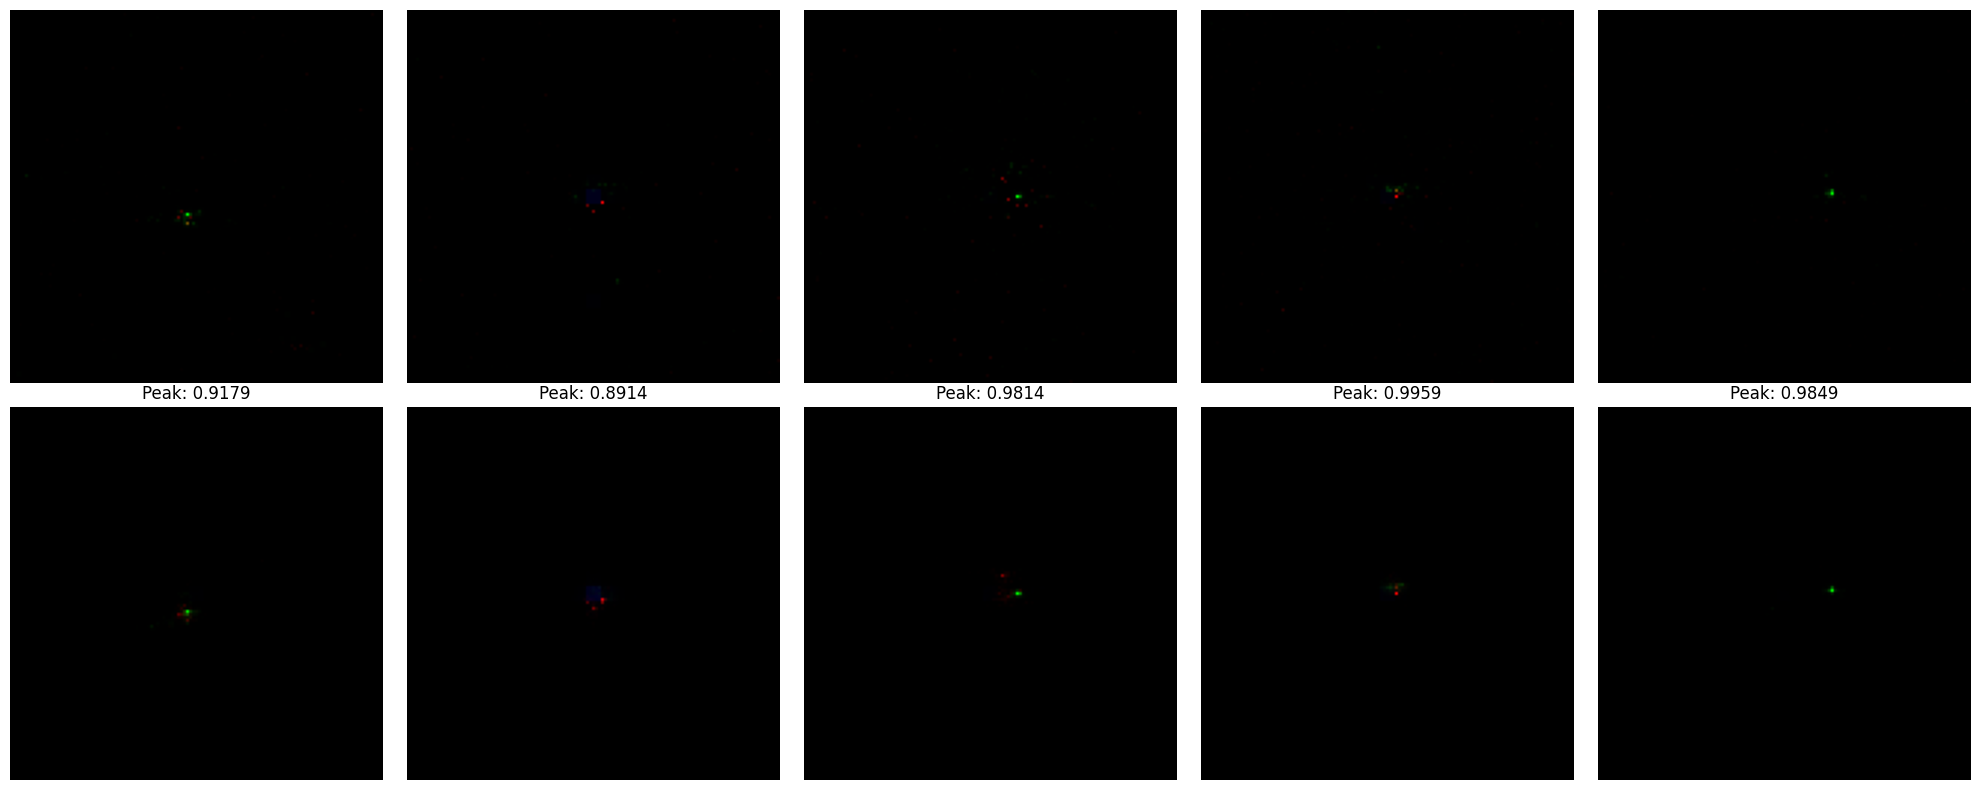

Epoch 930 | Train Loss 2.828 | Val Loss 78.883 | 23.5s
Step [100/123] | Loss: 2.8958 | Beta: 0.010
Epoch 931 | Train Loss 2.829 | Val Loss 77.447 | 23.3s
Step [100/123] | Loss: 2.9260 | Beta: 0.010
Epoch 932 | Train Loss 2.830 | Val Loss 77.200 | 22.9s
Step [100/123] | Loss: 2.7828 | Beta: 0.010
Epoch 933 | Train Loss 2.829 | Val Loss 76.945 | 23.4s
Step [100/123] | Loss: 2.8922 | Beta: 0.010
Epoch 934 | Train Loss 2.828 | Val Loss 77.802 | 23.1s
Step [100/123] | Loss: 2.8500 | Beta: 0.010
Epoch 935 | Train Loss 2.825 | Val Loss 76.715 | 23.0s
Step [100/123] | Loss: 2.9434 | Beta: 0.010
Epoch 936 | Train Loss 2.825 | Val Loss 77.825 | 23.2s
Step [100/123] | Loss: 2.8694 | Beta: 0.010
Epoch 937 | Train Loss 2.825 | Val Loss 77.384 | 23.1s
Step [100/123] | Loss: 2.7640 | Beta: 0.010
Epoch 938 | Train Loss 2.825 | Val Loss 76.283 | 23.1s
Step [100/123] | Loss: 2.8322 | Beta: 0.010
Epoch 939 | Train Loss 2.824 | Val Loss 78.057 | 23.2s
Step [100/123] | Loss: 2.8617 | Beta: 0.010
--- DEBUG 

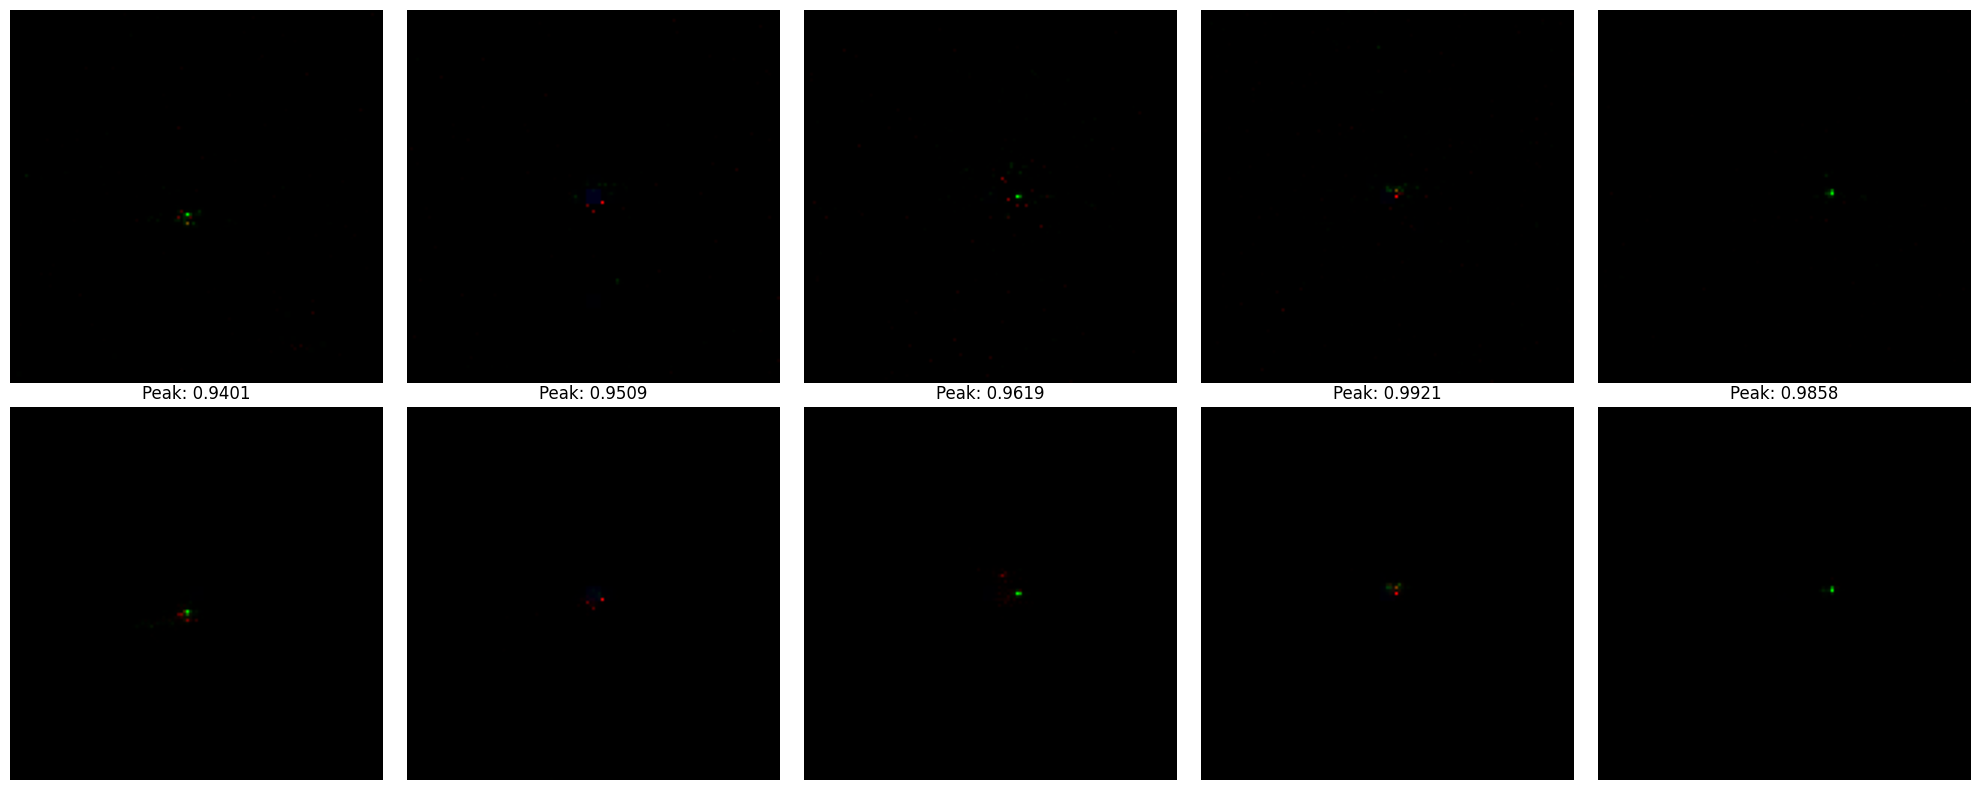

Epoch 940 | Train Loss 2.823 | Val Loss 78.408 | 23.7s
Step [100/123] | Loss: 2.7944 | Beta: 0.010
Epoch 941 | Train Loss 2.823 | Val Loss 76.895 | 23.1s
Step [100/123] | Loss: 2.7170 | Beta: 0.010
Epoch 942 | Train Loss 2.820 | Val Loss 76.952 | 23.1s
Step [100/123] | Loss: 2.7091 | Beta: 0.010
Epoch 943 | Train Loss 2.820 | Val Loss 77.616 | 22.8s
Step [100/123] | Loss: 2.7949 | Beta: 0.010
Epoch 944 | Train Loss 2.820 | Val Loss 76.237 | 22.9s
Step [100/123] | Loss: 2.8196 | Beta: 0.010
Epoch 945 | Train Loss 2.820 | Val Loss 77.951 | 22.9s
Step [100/123] | Loss: 2.9030 | Beta: 0.010
Epoch 946 | Train Loss 2.820 | Val Loss 76.760 | 22.9s
Step [100/123] | Loss: 2.8121 | Beta: 0.010
Epoch 947 | Train Loss 2.819 | Val Loss 77.470 | 23.1s
Step [100/123] | Loss: 2.8461 | Beta: 0.010
Epoch 948 | Train Loss 2.819 | Val Loss 77.664 | 22.9s
Step [100/123] | Loss: 2.8814 | Beta: 0.010
Epoch 949 | Train Loss 2.818 | Val Loss 77.106 | 22.9s
Step [100/123] | Loss: 2.7269 | Beta: 0.010
--- DEBUG 

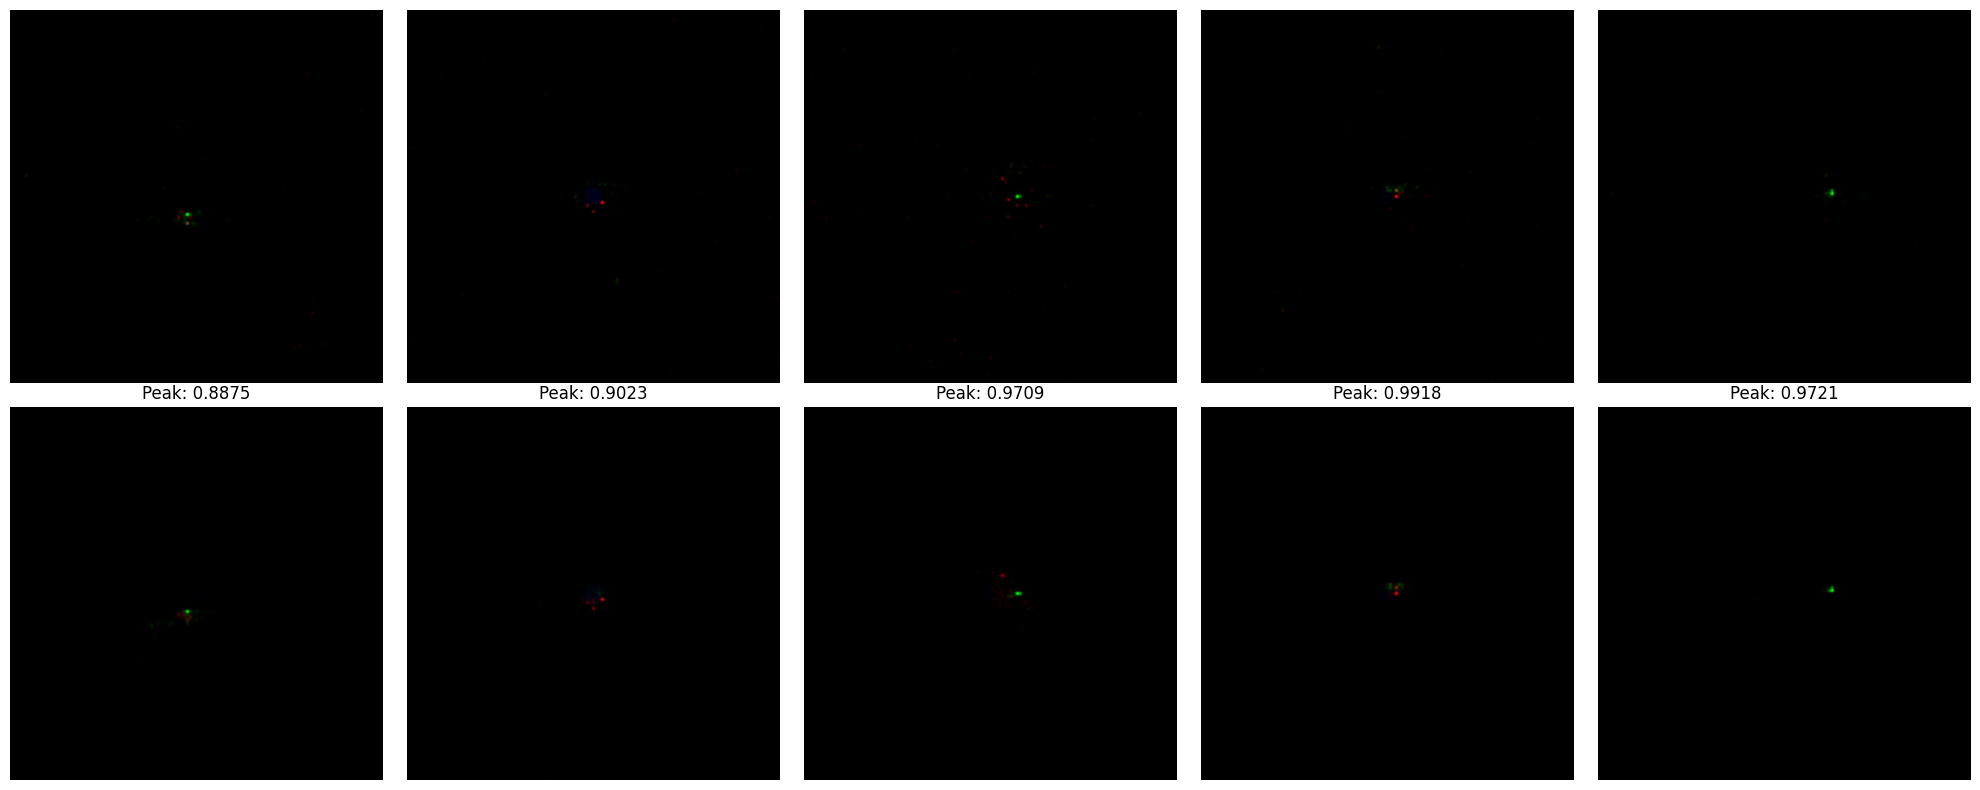

Epoch 950 | Train Loss 2.815 | Val Loss 78.477 | 23.5s
Step [100/123] | Loss: 2.8567 | Beta: 0.010
Epoch 951 | Train Loss 2.817 | Val Loss 78.091 | 22.8s
Step [100/123] | Loss: 2.7702 | Beta: 0.010
Epoch 952 | Train Loss 2.816 | Val Loss 76.605 | 22.9s
Step [100/123] | Loss: 2.7939 | Beta: 0.010
Epoch 953 | Train Loss 2.815 | Val Loss 77.089 | 22.7s
Step [100/123] | Loss: 2.7406 | Beta: 0.010
Epoch 954 | Train Loss 2.813 | Val Loss 76.272 | 22.9s
Step [100/123] | Loss: 2.8618 | Beta: 0.010
Epoch 955 | Train Loss 2.813 | Val Loss 78.383 | 22.8s
Step [100/123] | Loss: 2.7475 | Beta: 0.010
Epoch 956 | Train Loss 2.812 | Val Loss 77.277 | 22.9s


In [ ]:
# Hyperparameters & Configuration
BATCH_SIZE = 1024
EPOCHS = 1000
LR = 2e-4
RESUME = True  # Set to True to resume from last.pt

# 1. Initialize Dataset
dataset = JetImageDataset(x_jets_mem)
train_size = int(0.9 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset) - train_size])

# 2. Create DataLoaders (Optimized for RAM data)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 3. Initialize Model
model = VAE()

# 4. Training Loop
# Check if resume is requested and file exists
ckpt_path = os.path.join(OUTPUT_DIR, "last.pt")
history = train_vae(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, out_dir=OUTPUT_DIR,
    resume_path=ckpt_path if RESUME else None
)

# 5. Visualize Results
print("Training complete! Visualizing loss history...")
plot_training_history(history)